In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2"

In [2]:
import torch
from custom_vision_transformer import vit_custom
from training_utils import get_data_loaders
from types import SimpleNamespace
import matplotlib.pyplot as plt
from utils import *
from training_utils import val_one_epoch

In [3]:
params = SimpleNamespace(
    gpu_idx=1,
    num_classes=100,
    img_size=224,
    batch_size=128,
    bias_threshold=None,
    bias_topk=None
)

In [4]:
print("Number of visible GPUs :", torch.cuda.device_count())

torch.cuda.set_device(params.gpu_idx)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}:{torch.cuda.current_device()} {torch.cuda.get_device_name(torch.cuda.current_device())}" if torch.cuda.is_available() else "CPU")

Number of visible GPUs : 3
Device: cuda:1 NVIDIA RTX A4500


/home/cherr-24/venvs/venv1/lib/python3.12/site-packages/torch/cuda/__init__.py:371: UserWarning: Found GPU2 Quadro P400 which is of compute capability (CC) 6.1.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 12.0 which supports hardware CC >=12.0,<13.0
Please follow the instructions at https://pytorch.org/get-started/locally/ to install a PyTorch release that supports one of these CUDA versions: 12.6
  _warn_unsupported_code(d, device_cc, code_ccs)
/home/cherr-24/venvs/venv1/lib/python3.12/site-packages/torch/cuda/__init__.py:489: UserWarning: 
Quadro P400 with CUDA capability sm_61 is not compatible with the current PyTorch installation.
The current PyTorch install s

In [5]:
model = vit_custom(num_classes=params.num_classes, image_size=params.img_size, use_bias=True, bias_threshold=params.bias_threshold, bias_topk=params.bias_topk).to(device)
checkpoint = torch.load("training_checkpoints/checkpoint6/vit_custom_epoch_200.pth")
checkpoint = checkpoint["model_state_dict"]
checkpoint = convert_qkv_to_q_k_v(checkpoint)
model.load_state_dict(checkpoint)
model.eval();

In [6]:
train_loader, val_loader = get_data_loaders(batch_size=params.batch_size, persistent_workers=False, shuffle_val=True)

In [7]:
avg_loss, avg_acc, avg_acc_top5, avg_pruned_ratio = val_one_epoch(val_loader, model, torch.nn.CrossEntropyLoss(), device, wandb_log=False)
print(f"Validation Accuracy: {avg_acc:.4f}, Top-5 Accuracy: {avg_acc_top5:.4f}, Average Pruning Ratio: {avg_pruned_ratio:.4f}")

Validation Accuracy: 0.7932, Top-5 Accuracy: 0.9224, Average Pruning Ratio: 0.0000


TopK: 1.0, Accuracy: 0.7932, Top-5 Accuracy: 0.9224, Average Pruning Ratio: 0.0000


TopK: 0.9, Accuracy: 0.7906, Top-5 Accuracy: 0.9214, Average Pruning Ratio: 0.1015


TopK: 0.8, Accuracy: 0.7854, Top-5 Accuracy: 0.9170, Average Pruning Ratio: 0.2030


TopK: 0.7, Accuracy: 0.7794, Top-5 Accuracy: 0.9134, Average Pruning Ratio: 0.3046


TopK: 0.6, Accuracy: 0.7684, Top-5 Accuracy: 0.9088, Average Pruning Ratio: 0.4010


...

TopK: 0.4, Accuracy: 0.7112, Top-5 Accuracy: 0.8748, Average Pruning Ratio: 0.6041


TopK: 0.3, Accuracy: 0.6498, Top-5 Accuracy: 0.8280, Average Pruning Ratio: 0.7005


TopK: 0.2, Accuracy: 0.5504, Top-5 Accuracy: 0.7452, Average Pruning Ratio: 0.8020


TopK: 0.1, Accuracy: 0.3626, Top-5 Accuracy: 0.5846, Average Pruning Ratio: 0.9036


TopK: 0.0, Accuracy: 0.0732, Top-5 Accuracy: 0.2026, Average Pruning Ratio: 0.9949


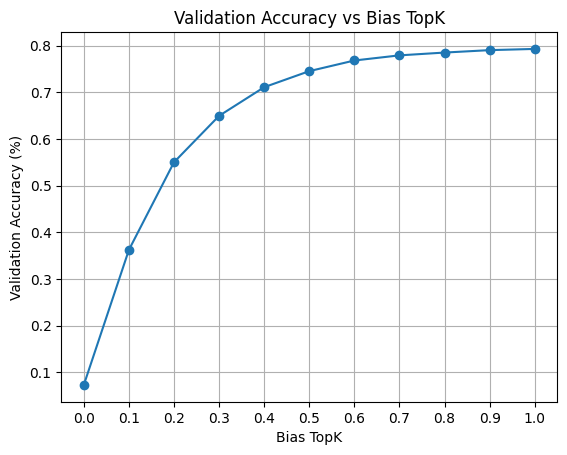

In [11]:
# plot accuracy en fonction du topk

topk_values = [[1.0]*12, [0.9]*12, [0.8]*12, [0.7]*12, [0.6]*12, [0.5]*12, [0.4]*12, [0.3]*12, [0.2]*12, [0.1]*12, [0.0]*12]
acc_values = []

for topk in topk_values:
    model = vit_custom(num_classes=params.num_classes, image_size=params.img_size, use_bias=True, bias_threshold=None, bias_topk=topk).to(device)
    checkpoint = torch.load("training_checkpoints/checkpoint6/vit_custom_epoch_200.pth")
    checkpoint = checkpoint["model_state_dict"]
    checkpoint = convert_qkv_to_q_k_v(checkpoint)
    model.load_state_dict(checkpoint)
    model.eval();

    avg_loss, avg_acc, avg_acc_top5, avg_pruned_ratio = val_one_epoch(val_loader, model, torch.nn.CrossEntropyLoss(), device, wandb_log=False)
    acc_values.append(avg_acc)
    print(f"TopK: {(mean(topk)):.1f}, Accuracy: {avg_acc:.4f}, Top-5 Accuracy: {avg_acc_top5:.4f}, Average Pruning Ratio: {avg_pruned_ratio:.4f}")

plt.plot([mean(k) for k in topk_values], acc_values, marker='o')
plt.title("Validation Accuracy vs Bias TopK")
plt.xlabel("Bias TopK")
plt.ylabel("Validation Accuracy (%)")
plt.xticks([mean(k) for k in topk_values])
plt.grid()
plt.show()

TopK: 1.0, Accuracy: 0.7932, Top-5 Accuracy: 0.9224, Average Pruning Ratio: 0.0000


TopK: 1.0, Accuracy: 0.7926, Top-5 Accuracy: 0.9228, Average Pruning Ratio: 0.0508


TopK: 0.9, Accuracy: 0.7920, Top-5 Accuracy: 0.9224, Average Pruning Ratio: 0.1015


TopK: 0.8, Accuracy: 0.7904, Top-5 Accuracy: 0.9214, Average Pruning Ratio: 0.1523


TopK: 0.8, Accuracy: 0.7892, Top-5 Accuracy: 0.9196, Average Pruning Ratio: 0.2005


...

TopK: 0.7, Accuracy: 0.7848, Top-5 Accuracy: 0.9172, Average Pruning Ratio: 0.3020


TopK: 0.7, Accuracy: 0.7826, Top-5 Accuracy: 0.9142, Average Pruning Ratio: 0.3503


TopK: 0.6, Accuracy: 0.7742, Top-5 Accuracy: 0.9102, Average Pruning Ratio: 0.4010


TopK: 0.5, Accuracy: 0.7578, Top-5 Accuracy: 0.9020, Average Pruning Ratio: 0.4518


TopK: 0.5, Accuracy: 0.5982, Top-5 Accuracy: 0.7842, Average Pruning Ratio: 0.4975


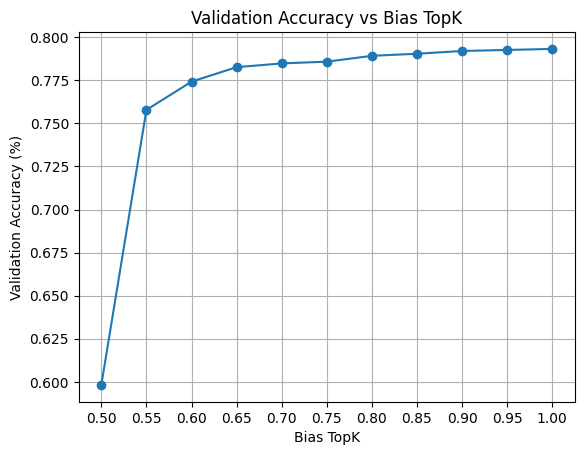

In [10]:
# plot accuracy en fonction du topk, mais avec pruning seulement sur les 6 dernières couches

topk_values = [[1.0]*6 + [1.0]*6, [1.0]*6 + [0.9]*6, [1.0]*6 + [0.8]*6, [1.0]*6 + [0.7]*6, [1.0]*6 + [0.6]*6, [1.0]*6 + [0.5]*6, [1.0]*6 + [0.4]*6, [1.0]*6 + [0.3]*6, [1.0]*6 + [0.2]*6, [1.0]*6 + [0.1]*6, [1.0]*6 + [0.0]*6]
acc_values = []

for topk in topk_values:
    model = vit_custom(num_classes=params.num_classes, image_size=params.img_size, use_bias=True, bias_threshold=None, bias_topk=topk).to(device)
    checkpoint = torch.load("training_checkpoints/checkpoint6/vit_custom_epoch_200.pth")
    checkpoint = checkpoint["model_state_dict"]
    checkpoint = convert_qkv_to_q_k_v(checkpoint)
    model.load_state_dict(checkpoint)
    model.eval();

    avg_loss, avg_acc, avg_acc_top5, avg_pruned_ratio = val_one_epoch(val_loader, model, torch.nn.CrossEntropyLoss(), device, wandb_log=False)
    acc_values.append(avg_acc)
    print(f"TopK: {(mean(topk)):.1f}, Accuracy: {avg_acc:.4f}, Top-5 Accuracy: {avg_acc_top5:.4f}, Average Pruning Ratio: {avg_pruned_ratio:.4f}")

plt.plot([mean(k) for k in topk_values], acc_values, marker='o')
plt.title("Validation Accuracy vs Bias TopK")
plt.xlabel("Bias TopK")
plt.ylabel("Validation Accuracy (%)")
plt.xticks([mean(k) for k in topk_values])
plt.grid()
plt.show()

Threshold: -3.0, Accuracy: 0.7944, Top-5 Accuracy: 0.9236, Average Pruning Ratio: 0.0153


Threshold: -2.5, Accuracy: 0.7942, Top-5 Accuracy: 0.9234, Average Pruning Ratio: 0.0491


Threshold: -2.0, Accuracy: 0.7944, Top-5 Accuracy: 0.9226, Average Pruning Ratio: 0.1162


Threshold: -1.5, Accuracy: 0.7900, Top-5 Accuracy: 0.9236, Average Pruning Ratio: 0.2203


Threshold: -1.0, Accuracy: 0.7812, Top-5 Accuracy: 0.9182, Average Pruning Ratio: 0.3523


Threshold: -0.5, Accuracy: 0.7598, Top-5 Accuracy: 0.9058, Average Pruning Ratio: 0.5140


Threshold: 0.0, Accuracy: 0.6842, Top-5 Accuracy: 0.8578, Average Pruning Ratio: 0.6906


Threshold: 0.5, Accuracy: 0.4612, Top-5 Accuracy: 0.6704, Average Pruning Ratio: 0.8160


Threshold: 1.0, Accuracy: 0.1852, Top-5 Accuracy: 0.3668, Average Pruning Ratio: 0.8722


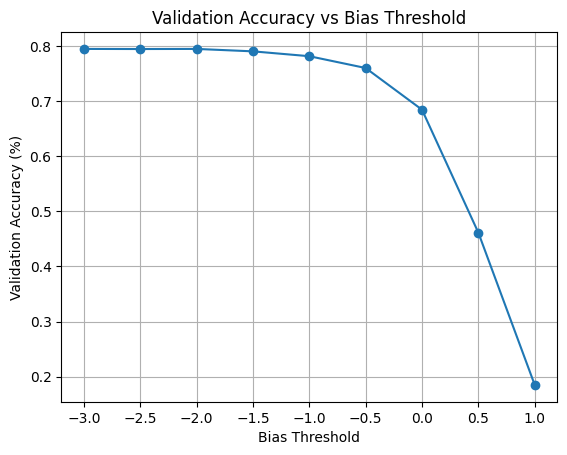

In [ ]:
# plot accuracy en fonction du nombre de neurones prunés (threshold)

threshold_values = [-3.0, -2.5, -2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0]
acc_values = []
avg_pruned_ratio_values = []

for threshold in threshold_values:
    model = vit_custom(num_classes=params.num_classes, image_size=params.img_size, use_bias=True, bias_threshold=threshold, bias_topk=None).to(device)
    checkpoint = torch.load("training_checkpoints/checkpoint6/vit_custom_epoch_200.pth")
    checkpoint = checkpoint["model_state_dict"]
    checkpoint = convert_qkv_to_q_k_v(checkpoint)
    model.load_state_dict(checkpoint)
    model.eval();

    avg_loss, avg_acc, avg_acc_top5, avg_pruned_ratio = val_one_epoch(val_loader, model, torch.nn.CrossEntropyLoss(), device, wandb_log=False)
    acc_values.append(avg_acc)
    avg_pruned_ratio_values.append(avg_pruned_ratio)
    print(f"Threshold: {threshold:.1f}, Accuracy: {avg_acc:.4f}, Top-5 Accuracy: {avg_acc_top5:.4f}, Average Pruning Ratio: {avg_pruned_ratio:.4f}")

plt.plot(threshold_values, acc_values, marker='o')
plt.title("Validation Accuracy vs Bias Threshold")
plt.xlabel("Bias Threshold")
plt.ylabel("Validation Accuracy (%)")
plt.xticks(threshold_values)
plt.grid()
plt.show()